<h2>Code Snippets for Generating Figures (and Selective Tables)Given in Paper</h2>

<h4>1. Table 1: Distribution of Stack Exchange Sites into Technology and Non-Technology Sites</h4>

<p>In order to generate Table 1: Distribution of Stack Exchange Sites into Technology & Non-Technology Sites, we saved a copy of <a href="https://stackexchange.com/sites">all sites page</a> of Stack Exchange as a HTML page and named it <i>All Sites - Stack Exchange.html</i>. The following code snippet extracts the site name and category information from the HTML file and generates the summary of site count per category.</p>

In [5]:
from bs4 import BeautifulSoup
import pandas as pd

# Step 1: Load local HTML file
with open("All Sites - Stack Exchange.html", "r", encoding="utf-8") as f:
    html = f.read()

soup = BeautifulSoup(html, "html.parser")
div = soup.find("div", class_="list-view-container")

# Step 2: Loop through site cards
sites = []
site_item = div.find_all("div", class_="lv-item")

print(len(site_item))
for d in site_item:
    site={}
    answer= ''
    name = ''
    category=''
    if(d.find('div', class_='lv-info')):
        name = d.find("h2").find("a").text
        classes = d.get("class", [])  # get list of all classes
        category = next((c for c in classes if c.startswith("category-")), None)

       
    if(d.find_all('div', class_='lv-stats-box')):
        answer= d.find_all("div", class_="lv-stats-box")[2].text
    site = {"name": name,"category": category.replace('category-', ''),     "% answered": answer.strip().replace('% answered', '')      
    }
    sites.append(site)

# Step 3: Save to CSV or display
df = pd.DataFrame(sites)
df.to_csv("stackexchange_sites_extracted.csv", index=False)
summary = df.groupby("category").size().reset_index(name="count")
print(summary)

182
                  name    category % answered
0       Stack Overflow  technology         70
1         Server Fault  technology         76
2           Super User  technology         66
3  Meta Stack Exchange  technology         87
4     Web Applications  technology         82
**********
            category  count
0           business      3
1  culturerecreation     46
2           lifearts     25
3       professional      7
4            science     24
5         technology     77


<h4>2. Figure 1: Data not included in existing preprocessed Stack Overflow data dumps based on January 2026 data dump</h4>

<h5>2.1 New Users Joining Stack Overflow Each Year</h5>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyodbc

import pandas as pd
import pyodbc
server='DESKTOP-EQTUGG1'
database = 'StackOverflowUsersDb_Oct2025' 
cnxn = pyodbc.connect('DRIVER={SQL Server};SERVER='+server+';DATABASE='+database+';')
cursor = cnxn.cursor()

query = """SELECT  Year([CreationDate]) as JoinedIn, count(*) as Users
  FROM [StackOverflowUsersDb_Oct2025].[dbo].[StackOverflowUsers]
  group by Year([CreationDate])
  order by Year([CreationDate])"""
df_users = pd.read_sql(query, cnxn)
cnxn.close()
years = df_users["JoinedIn"].astype(int)
counts = df_users["Users"]
total = counts.sum()
x = np.arange(len(years))

C:\Users\Admin\AppData\Local\Temp\ipykernel_1140\2586309998.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_users = pd.read_sql(query, cnxn)


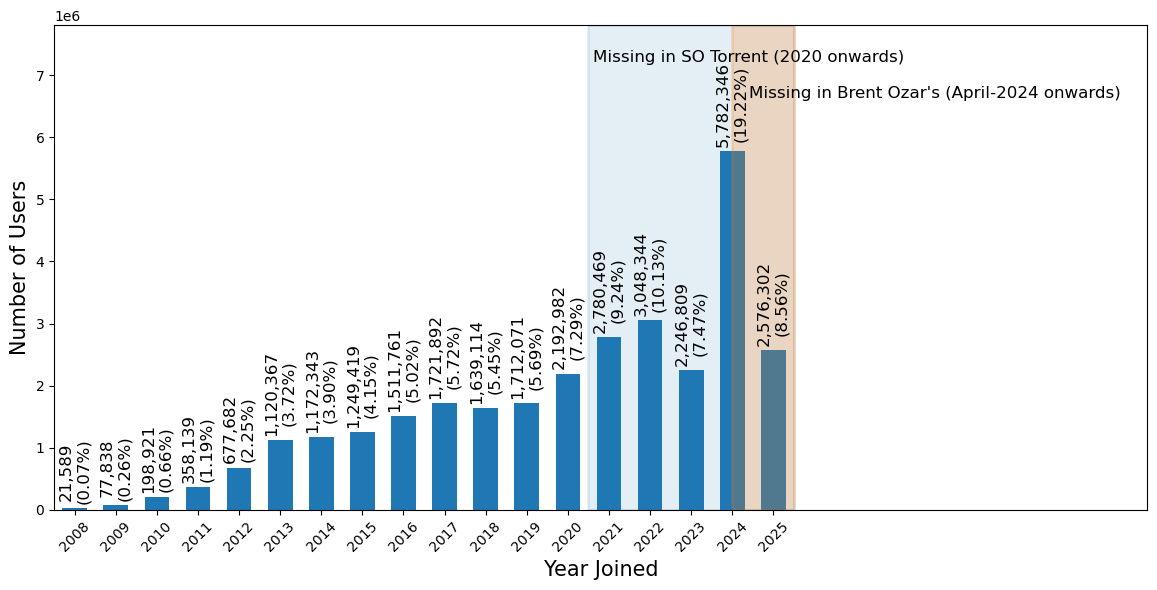

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(x, counts, width=0.6)

ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45)
ax.set_xlabel("Year Joined", fontsize=15)
ax.set_ylabel("Number of Users", fontsize=15)

y_max = counts.max()
ax.set_ylim(0, y_max * 1.35)
years_list = years.tolist()

# -----------------------------
# Helper
# -----------------------------
def year_to_x(year):
    return years_list.index(year)

end_all = len(years_list) - 0.5  # chart end
ax.set_xlim(-0.5, end_all + 8.6)

# -----------------------------
# Growth phase 1: 2019 → end
# (start of year)
# -----------------------------
start_2018 = year_to_x(2021) - 0.5

ax.axvspan(
    start_2018,
    end_all,
    alpha=0.12,
    facecolor="tab:blue",
    edgecolor="tab:blue",
    linewidth=2,
    zorder=1
)

# -----------------------------
# Growth phase 2: 2025 → end
# (mid-year start)
# -----------------------------
start_2024 = year_to_x(2024)

ax.axvspan(
    start_2024,
    end_all,
    alpha=0.22,
    facecolor="tab:orange",
    edgecolor="tab:orange",
    linewidth=2,
    zorder=2
)

# -----------------------------
# Bar annotations
# -----------------------------
for bar, value in zip(bars, counts):
    pct = (value / total) * 100
    label = f"{value:,}\n({pct:.2f}%)"

    ax.annotate(
        label,
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=12
    )

# -----------------------------
# Growth phase labels
# -----------------------------
ax.text(
    start_2018 + 0.1,
    y_max * 1.28,
    "Missing in SO Torrent (2020 onwards)",
    fontsize=12,
    va="top"
)

ax.text(
    start_2024 + 0.4,
    y_max * 1.18,
    "Missing in Brent Ozar's (April-2024 onwards)",
    fontsize=12,
    va="top"
)

plt.tight_layout()
plt.show()

<h5>2.2 New Posts Created on Stack Overflow Each Year</h5>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyodbc

import pandas as pd
import pyodbc
server='DESKTOP-EQTUGG1'
database = 'StackOverflowPostsDb_Oct2025' 
cnxn = pyodbc.connect('DRIVER={SQL Server};SERVER='+server+';DATABASE='+database+';')
cursor = cnxn.cursor()

query = """SELECT  Year([CreationDate]) as CreatedIn, count(*) as Posts
  FROM [StackOverflowPostsDb_Oct2025].[dbo].[StackOverflowPosts]
  group by Year([CreationDate])
  order by Year([CreationDate])"""
df = pd.read_sql(query, cnxn)
cnxn.close()

C:\Users\Admin\AppData\Local\Temp\ipykernel_1140\938336666.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnxn)


<p><b>Execution Time: </b> 00:32:37</p>

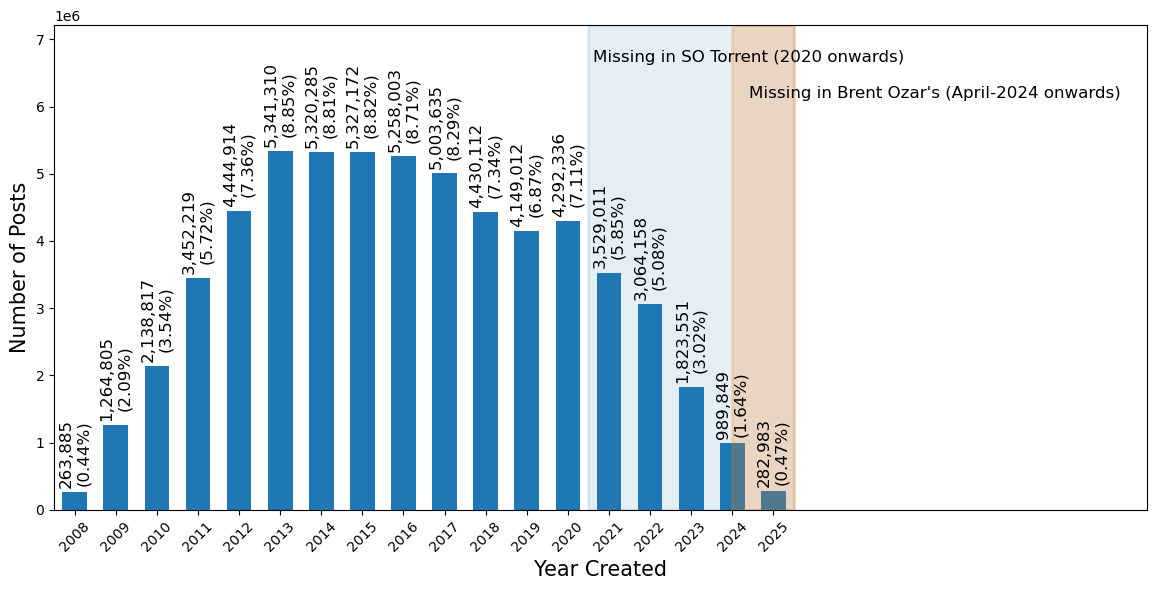

In [17]:
years = df["CreatedIn"].astype(int)
counts = df["Posts"]
total = counts.sum()
x = np.arange(len(years))
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(x, counts, width=0.6)

ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45)
ax.set_xlabel("Year Created", fontsize=15)
ax.set_ylabel("Number of Posts", fontsize=15)

y_max = counts.max()
ax.set_ylim(0, y_max * 1.35)

# -----------------------------
# Helper
# -----------------------------
def year_to_x(year):
    return years_list.index(year)

end_all = len(years_list) - 0.5  # chart end
ax.set_xlim(-0.5, end_all + 8.6)

# -----------------------------
# Growth phase 1: 2019 → end
# (start of year)
# -----------------------------
start_2018 = year_to_x(2021) - 0.5

ax.axvspan(
    start_2018,
    end_all,
    alpha=0.12,
    facecolor="tab:blue",
    edgecolor="tab:blue",
    linewidth=2,
    zorder=1
)

# -----------------------------
# Growth phase 2: 2025 → end
# (mid-year start)
# -----------------------------
start_2024 = year_to_x(2024)

ax.axvspan(
    start_2024,
    end_all,
    alpha=0.22,
    facecolor="tab:orange",
    edgecolor="tab:orange",
    linewidth=2,
    zorder=2
)

# -----------------------------
# Bar annotations
# -----------------------------
for bar, value in zip(bars, counts):
    pct = (value / total) * 100
    label = f"{value:,}\n({pct:.2f}%)"

    ax.annotate(
        label,
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=12
    )

# -----------------------------
# Growth phase labels
# -----------------------------
ax.text(
    start_2018 + 0.1,
    y_max * 1.28,
    "Missing in SO Torrent (2020 onwards)",
    fontsize=12,
    va="top"
)

ax.text(
    start_2024 + 0.4,
    y_max * 1.18,
    "Missing in Brent Ozar's (April-2024 onwards)",
    fontsize=12,
    va="top"
)

plt.tight_layout()
plt.show()

<h4>3. Figure 2: Increasing Size of Stack Overflow Data Dumps</h4>

C:\Users\Admin\AppData\Local\Temp\ipykernel_1140\1873217221.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(versions)


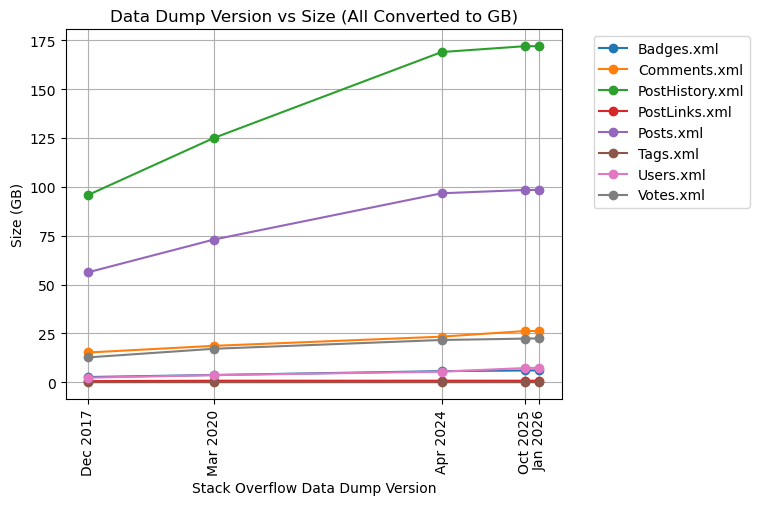

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

versions = ['Dec 2017', 'Mar 2020', 'Apr 2024','Oct 2025', 'Jan 2026']

# convert to datetime
dates = pd.to_datetime(versions)

data = {
    'Badges.xml': [(2.65, 'GB'),(3.68, 'GB'), (5.65, 'GB'), (5.99, 'GB'), (6.02, 'GB')],
    'Comments.xml': [(15.2, 'GB'), (18.6, 'GB'),(23.3, 'GB'), (26.2, 'GB'), (26.2, 'GB')],
     'PostHistory.xml': [(95.9, 'GB'),(125, 'GB'), (169, 'GB'), (172, 'GB'), (172, 'GB')],
    'PostLinks.xml': [(543, 'MB'), (758, 'MB'), (768, 'MB'), (767, 'MB'), (766, 'MB')],
     'Posts.xml': [(56.3, 'GB'), (73.0, 'GB'), (96.7, 'GB'), (98.4, 'GB'), (98.4, 'GB')],
    'Tags.xml': [(4.32, 'MB'), (4.92, 'MB'),(5.56, 'MB'), (5.60, 'MB'), (5.60, 'MB')],
     'Users.xml': [(2.3, 'GB'), (3.61, 'GB'), (5.38, 'GB'),(7.25, 'GB'), (7.36, 'GB')],
    'Votes.xml': [(12.7, 'GB'), (17.1, 'GB'), (21.6, 'GB'), (22.3, 'GB'), (22.4, 'GB')],
}
def convert_to_gb(value, unit):
    if unit == 'MB':
        return value / 1024
    return value

converted_data = {}

for key, values in data.items():
    converted_sizes = []
    for value, unit in values:
        converted_sizes.append(convert_to_gb(value, unit))
    converted_data[key] = converted_sizes

# Plot lines
for key, sizes in converted_data.items():
    plt.plot(dates, sizes, marker='o', label=key)

ax = plt.gca()

# quarterly ticks (including missing quarters)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# label only selected versions
ax.set_xticks(dates)
ax.set_xticklabels(versions)
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Stack Overflow Data Dump Version")
plt.ylabel("Size (GB)")
plt.title("Data Dump Version vs Size (All Converted to GB)")
plt.grid(True)

plt.show()

<h4>4. Figure 3: Scalability - Time versus Data Dump Size Per File Across Data Dump Versions</h4>

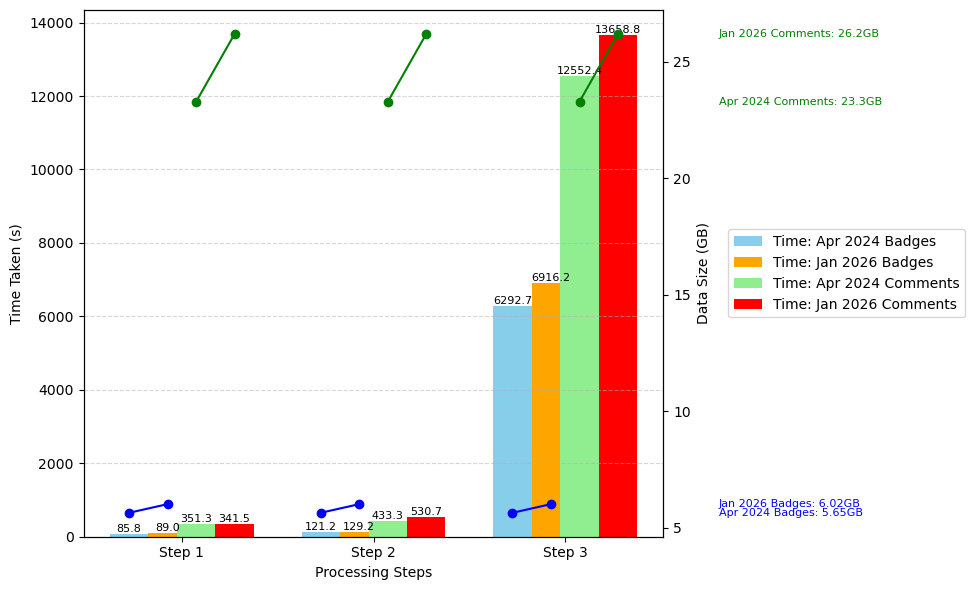

In [2]:
import numpy as np
import matplotlib.pyplot as plt

steps = ['Step 1', 'Step 2', 'Step 3']

# -------------------------
# Data
# -------------------------
time_2024_B = [85.768, 121.25, 6292.74]
time_2024_C = [351.26,433.33, 12552.36]
time_2026_B = [88.953, 129.25, 6916.17]
time_2026_C = [341.465, 530.73, 13658.76]


size_2024_B_GB = 5.65
size_2026_B_GB = 6.02
size_2024_C_GB = 23.3
size_2026_C_GB = 26.2
# -------------------------
# Plotting
# -------------------------

x = np.arange(len(steps))
width = 0.2
gap = 0.15  # gap between file groups

# Make the figure wider to fit legend and labels
fig, ax1 = plt.subplots(figsize=(12, 6))

# x positions for grouped bars
x_B2024 = x - width - gap/2
x_B2026 = x - gap/2
x_C2024 = x + gap/2
x_C2026 = x + width + gap/2

# Plot bars: time per file/version
bars_2024_B = ax1.bar(x_B2024, time_2024_B, width, color='skyblue', label='Time: Apr 2024 Badges')
bars_2026_B = ax1.bar(x_B2026, time_2026_B, width, color='orange', label='Time: Jan 2026 Badges')
bars_2024_C = ax1.bar(x_C2024, time_2024_C, width, color='lightgreen', label='Time: Apr 2024 Comments')
bars_2026_C = ax1.bar(x_C2026, time_2026_C, width, color='red', label='Time: Jan 2026 Comments')

ax1.set_xlabel('Processing Steps')
ax1.set_ylabel('Time Taken (s)')
ax1.set_xticks(x)
ax1.set_xticklabels(steps)
# ax1.set_title('Scalability: Time vs Data Size per File Across Data Dump Versions')
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

# Annotate bars with time values
for bars in [bars_2024_B, bars_2026_B, bars_2024_C, bars_2026_C]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + 0.3, f'{height:.1f}', 
                 ha='center', va='bottom', fontsize=8, )

# Secondary y-axis for dataset size
ax2 = ax1.twinx()

# Plot markers and connect 2024 -> 2026 per file for slope demonstration
for i in range(len(steps)):
    # File B
    ax2.plot([x_B2024[i], x_B2026[i]], [size_2024_B_GB, size_2026_B_GB], 'o-', color='blue', markersize=6)
    # File C
    ax2.plot([x_C2024[i], x_C2026[i]], [size_2024_C_GB, size_2026_C_GB], 'o-', color='green', markersize=6)

ax2.set_ylabel('Data Size (GB)')

# Annotate dataset sizes on the extreme right (after last step)
x_right = x[-1] + 0.8  # extra space to avoid legend
ax2.text(x_right, size_2024_B_GB, f'Apr 2024 Badges: {size_2024_B_GB}GB', color='blue', fontsize=8, va='center')
ax2.text(x_right, size_2026_B_GB, f'Jan 2026 Badges: {size_2026_B_GB}GB', color='blue', fontsize=8, va='center')
ax2.text(x_right, size_2024_C_GB, f'Apr 2024 Comments: {size_2024_C_GB}GB', color='green', fontsize=8, va='center')
ax2.text(x_right, size_2026_C_GB, f'Jan 2026 Comments: {size_2026_C_GB}GB', color='green', fontsize=8, va='center')

# Add combined legend outside the plot (further right)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center left', bbox_to_anchor=(1.1, 0.5))

# Adjust layout to leave space on the right
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

<h4>Cross Site Validation to Extend the Approach Beyond Stack Overflow</h4>

To save data dumps of 12 Q&A sites considered in this section, we first downloaded the data dumps. We then extracted the data dumps (compressed 7zip files) using power shell. The following script was executed from the root folder containing subdirectories for each of the site. Each subdirectory contained the 7zip file.

<h5>1. Extract all 7zip files inside the sub folders</h5>

<h5>2. Delete all non-xml files inside each directory (e.g. 7zip, md files)</h5>

<h5>3. Generating Create Table Statements</h5>

Instead of storing data of each site in a single table e.g. a single table <i>Badges</i> we will saved them in separate tables e.g. <i>Badges_ServerFault</i>. The following scripts can be used to generate create table scripts for creating these tables. These snippets will save the SQL scripts in an output file which you can run using SSMS.

<h6>3.1 Create Table Statements for Badges Tables</h6>

In [47]:
import os

# Root folder containing all subdirectories
root_dir = r"E:\Learning\2026"

# Database table prefix / general naming scheme
file_prefix = "Badges"  

# Get all subdirectory names
subdirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]

# CREATE TABLE template
create_table_template = """
CREATE TABLE [{table_name}] (
   AutoIdPK int Identity(1,1) NOT NULL,
				Id int, 
				UserId int, 
				Name nvarchar(50),
				Date datetime,
				Class tinyint, 
				TagBased bit,
                CONSTRAINT PK_AutoIdPK_{table_name} PRIMARY KEY CLUSTERED (AutoIdPK)
);
"""

# Generate CREATE TABLE statements
sql_statements = []
for subdir in subdirs:
    table_name = f"{file_prefix}_{subdir}"
    sql_statements.append(create_table_template.format(table_name=table_name))

# Output to a .sql file
output_file = rf"E:\Learning\2026\output_create_tables_{file_prefix}.sql"
# output_file = r"E:\Learning\2026\output_create_tables.sql"
with open(output_file, "w") as f:
    f.write("\n".join(sql_statements))

print(f"Generated {len(sql_statements)} CREATE TABLE statements in {output_file}")

Generated 27 CREATE TABLE statements in E:\Learning\2026\output_create_tables_Badges.sql


<h6>3.2 Create Table Statements for Comments Tables</h6>

In [48]:
import os

# Root folder containing all subdirectories
root_dir = r"E:\Learning\2026"

# Database table prefix / general naming scheme
file_prefix = "Comments"  

# Get all subdirectory names
subdirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]


create_table_template = """
CREATE TABLE [{table_name}] (
  AutoIdPK int Identity(1,1) NOT NULL,
				Id int, 
				PostId int,
				Score int,
				Text nvarchar(600),
				CreationDate datetime,
				UserDisplayName nvarchar(40),
				UserId int,
				ContentLicense varchar(30),
				CONSTRAINT PK_AutoIdPK_{table_name} PRIMARY KEY CLUSTERED (AutoIdPK)
);
"""

# Generate CREATE TABLE statements
sql_statements = []
for subdir in subdirs:
    table_name = f"{file_prefix}_{subdir}"
    sql_statements.append(create_table_template.format(table_name=table_name))

# Output to a .sql file
output_file = rf"E:\Learning\2026\output_create_tables_{file_prefix}.sql"
# output_file = r"E:\Learning\2026\output_create_tables.sql"
with open(output_file, "w") as f:
    f.write("\n".join(sql_statements))

print(f"Generated {len(sql_statements)} CREATE TABLE statements in {output_file}")

Generated 27 CREATE TABLE statements in E:\Learning\2026\output_create_tables_Comments.sql


<h6>3.3 Create Table Statements for PostHistory Tables</h6>

In [49]:
import os

# Root folder containing all subdirectories
root_dir = r"E:\Learning\2026"

# Database table prefix / general naming scheme
file_prefix = "PostHistory"  

# Get all subdirectory names
subdirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]


create_table_template = """
CREATE TABLE [{table_name}] (
 AutoIdPK int Identity(1,1) NOT NULL,
				Id int, 
				PostHistoryTypeId tinyint,
				PostId int,
				RevisionGUID uniqueidentifier,
				CreationDate datetime,
				UserId int, 
				UserDisplayName nvarchar(400),
				Comment nvarchar(400),
				Text nvarchar(max),
				ContentLicense varchar(30),
                CONSTRAINT PK_AutoIdPK_{table_name} PRIMARY KEY CLUSTERED (AutoIdPK)
);
"""

# Generate CREATE TABLE statements
sql_statements = []
for subdir in subdirs:
    table_name = f"{file_prefix}_{subdir}"
    sql_statements.append(create_table_template.format(table_name=table_name))

# Output to a .sql file
output_file = rf"E:\Learning\2026\output_create_tables_{file_prefix}.sql"
# output_file = r"E:\Learning\2026\output_create_tables.sql"
with open(output_file, "w") as f:
    f.write("\n".join(sql_statements))

print(f"Generated {len(sql_statements)} CREATE TABLE statements in {output_file}")

Generated 27 CREATE TABLE statements in E:\Learning\2026\output_create_tables_PostHistory.sql


<h6>3.4 Create Table Statements for PostLinks Tables</h6>

In [50]:
import os

# Root folder containing all subdirectories
root_dir = r"E:\Learning\2026"

# Database table prefix / general naming scheme
file_prefix = "PostLinks"  

# Get all subdirectory names
subdirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]


create_table_template = """
CREATE TABLE [{table_name}] (
 AutoIdPK int Identity(1,1) NOT NULL,
				Id bigint, 
				CreationDate datetime,
				PostId int, 
				RelatedPostId int,
				LinkTypeId tinyint,
                CONSTRAINT PK_AutoIdPK_{table_name} PRIMARY KEY CLUSTERED (AutoIdPK)
);
"""

# Generate CREATE TABLE statements
sql_statements = []
for subdir in subdirs:
    table_name = f"{file_prefix}_{subdir}"
    sql_statements.append(create_table_template.format(table_name=table_name))

# Output to a .sql file
output_file = rf"E:\Learning\2026\output_create_tables_{file_prefix}.sql"
# output_file = r"E:\Learning\2026\output_create_tables.sql"
with open(output_file, "w") as f:
    f.write("\n".join(sql_statements))

print(f"Generated {len(sql_statements)} CREATE TABLE statements in {output_file}")

Generated 27 CREATE TABLE statements in E:\Learning\2026\output_create_tables_PostLinks.sql


<h6>3.5 Create Table Statements for Posts Tables</h6>

In [51]:
import os

# Root folder containing all subdirectories
root_dir = r"E:\Learning\2026"

# Database table prefix / general naming scheme
file_prefix = "Posts"  

# Get all subdirectory names
subdirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]


create_table_template = """
CREATE TABLE [{table_name}] (
 AutoIdPK int Identity(1,1) NOT NULL,
				Id int, 
				PostTypeId tinyint,
				AcceptedAnswerId int,
				ParentId int,
				CreationDate datetime,
				DeletionDate datetime, 
				Score int,
				ViewCount int,
				Body nvarchar(max),
				OwnerUserId int,
				OwnerDisplayName nvarchar(40),
				LastEditorUserId int,
				LastEditorDisplayName nvarchar(40), 
				LastEditDate datetime,
				LastActivityDate datetime,
				Title nvarchar(250),
				Tags nvarchar(4000),
				AnswerCount int,
				CommentCount int, 
				FavoriteCount int, 
				ClosedDate datetime,
				CommunityOwnedDate datetime,
				ContentLicense varchar(30), 
                CONSTRAINT PK_AutoIdPK_{table_name} PRIMARY KEY CLUSTERED (AutoIdPK)
);
"""

# Generate CREATE TABLE statements
sql_statements = []
for subdir in subdirs:
    table_name = f"{file_prefix}_{subdir}"
    sql_statements.append(create_table_template.format(table_name=table_name))

# Output to a .sql file
output_file = rf"E:\Learning\2026\output_create_tables_{file_prefix}.sql"
# output_file = r"E:\Learning\2026\output_create_tables.sql"
with open(output_file, "w") as f:
    f.write("\n".join(sql_statements))

print(f"Generated {len(sql_statements)} CREATE TABLE statements in {output_file}")

Generated 27 CREATE TABLE statements in E:\Learning\2026\output_create_tables_Posts.sql


<h6>3.6  Create Table Statements for Tags Tables</h6>

In [52]:
import os

# Root folder containing all subdirectories
root_dir = r"E:\Learning\2026"

# Database table prefix / general naming scheme
file_prefix = "Tags"  

# Get all subdirectory names
subdirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]


create_table_template = """
CREATE TABLE [{table_name}] (
 AutoIdPK int Identity(1,1) NOT NULL,
				Id int, 
				TagName nvarchar(35),
				TagCount int, 
				ExcerptPostId int,
				WikiPostId int,
                CONSTRAINT PK_AutoIdPK_{table_name}  PRIMARY KEY CLUSTERED (AutoIdPK)
);
"""

# Generate CREATE TABLE statements
sql_statements = []
for subdir in subdirs:
    table_name = f"{file_prefix}_{subdir}"
    sql_statements.append(create_table_template.format(table_name=table_name))

# Output to a .sql file
output_file = rf"E:\Learning\2026\output_create_tables_{file_prefix}.sql"
# output_file = r"E:\Learning\2026\output_create_tables.sql"
with open(output_file, "w") as f:
    f.write("\n".join(sql_statements))

print(f"Generated {len(sql_statements)} CREATE TABLE statements in {output_file}")

Generated 27 CREATE TABLE statements in E:\Learning\2026\output_create_tables_Tags.sql


<h6>3.7 Create Table Statements for Users Tables</h6>

In [53]:
import os

# Root folder containing all subdirectories
root_dir = r"E:\Learning\2026"

# Database table prefix / general naming scheme
file_prefix = "Users"  

# Get all subdirectory names
subdirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]


create_table_template = """
CREATE TABLE [{table_name}] (
 AutoIdPK int Identity(1,1) NOT NULL,
				Id int, 
				Reputation int, 
				CreationDate datetime,
				DisplayName nvarchar(40),
				LastAccessDate datetime,
				WebsiteUrl nvarchar(200), 
				Location nvarchar(100), 
				AboutMe nvarchar(max),
				Views int, 
				Upvotes int, 
				DownVotes int, 
				ProfileImageUrl nvarchar(200), 
				AccountId int,
                CONSTRAINT PK_AutoIdPK_{table_name} PRIMARY KEY CLUSTERED (AutoIdPK)
);
"""

# Generate CREATE TABLE statements
sql_statements = []
for subdir in subdirs:
    table_name = f"{file_prefix}_{subdir}"
    sql_statements.append(create_table_template.format(table_name=table_name))

# Output to a .sql file
output_file = rf"E:\Learning\2026\output_create_tables_{file_prefix}.sql"
# output_file = r"E:\Learning\2026\output_create_tables.sql"
with open(output_file, "w") as f:
    f.write("\n".join(sql_statements))

print(f"Generated {len(sql_statements)} CREATE TABLE statements in {output_file}")

Generated 27 CREATE TABLE statements in E:\Learning\2026\output_create_tables_Users.sql


<h6>3.8 Create Table Statements for Votes Tables</h6>

In [54]:
import os

# Root folder containing all subdirectories
root_dir = r"E:\Learning\2026"

# Database table prefix / general naming scheme
file_prefix = "Votes"  

# Get all subdirectory names
subdirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]


create_table_template = """
CREATE TABLE [{table_name}] (
 AutoIdPK int Identity(1,1) NOT NULL,
				Id int, 
				PostId int, 
				VoteTypeId tinyint,
				UserId int,
				CreationDate datetime,
				BountyAmount int,
                CONSTRAINT PK_AutoIdPK_{table_name} PRIMARY KEY CLUSTERED (AutoIdPK)
);
"""

# Generate CREATE TABLE statements
sql_statements = []
for subdir in subdirs:
    table_name = f"{file_prefix}_{subdir}"
    sql_statements.append(create_table_template.format(table_name=table_name))

# Output to a .sql file
output_file = rf"E:\Learning\2026\output_create_tables_{file_prefix}.sql"
# output_file = r"E:\Learning\2026\output_create_tables.sql"
with open(output_file, "w") as f:
    f.write("\n".join(sql_statements))

print(f"Generated {len(sql_statements)} CREATE TABLE statements in {output_file}")

Generated 27 CREATE TABLE statements in E:\Learning\2026\output_create_tables_Votes.sql


<h5>4. Rearragning XML Files from Site Specific to Data Specific Directories </h5>

The following code snippet will rearrange the data dump files such that Badges related files (from each sites data dump) are placed inside Badges folder and so on. 

In [ ]:
import os
import shutil

# Root directory
root_dir = r"E:\Learning\2026"

file_names = [
    "Badges.xml",
    "Comments.xml",
    "PostHistory.xml",
    "PostLinks.xml",
    "Posts.xml",
    "Tags.xml",
    "Users.xml",
    "Votes.xml"
]

subdirs = [
    d for d in os.listdir(root_dir)
    if os.path.isdir(os.path.join(root_dir, d)) and not d.startswith("File")
]

# Process each file type
for file_name in file_names:
    # Create folder name like Posts, Comments, etc.
    base_name = os.path.splitext(file_name)[0]
    target_dir = os.path.join(root_dir, f"{base_name}")

    os.makedirs(target_dir, exist_ok=True)

    # Loop through each subdirectory
    for subdir in subdirs:
        source_file = os.path.join(root_dir, subdir, file_name)

        if os.path.exists(source_file):
            # Rename: Posts_A.xml, Posts_B.xml, etc.
            new_name = f"{base_name}_{subdir}.xml"
            destination = os.path.join(target_dir, new_name)

            shutil.move(source_file, destination)
            print(f"Moved: {source_file} -> {destination}")
        else:
            print(f"Missing: {source_file}")

<h5>5. Inserting Data into Tables</h5>

We have slightly modified the original scripts given in the paper to change the table name in the corresponding insert statements.

<h6>5.1 Badges Tables</h6>

In [ ]:
import pandas as pd
import pyodbc
import glob
import os
import time
server = 'DESKTOP-EQTUGG1'
database = 'StackExchangeSitesData_Jan2026' 

cnxn = pyodbc.connect('DRIVER={ODBC Driver 17 for SQL Server};SERVER='+server+';DATABASE='+database+';Trusted_Connection=yes;')
cursor = cnxn.cursor()

badges_xml_path =r'E:\Learning\2026\Badges'

for filename in glob.glob(os.path.join(badges_xml_path, '*')):
    start_time = time.perf_counter()
    # Extract filename without extension
    name = os.path.splitext(os.path.basename(filename))[0]
    badges_df = pd.read_xml(filename)
    badges_df = badges_df.fillna(0)

    query = f"insert into {name} (Id, UserId, Name, Date, Class,TagBased) values (?,?,?,?,?,?)"
    # print(query)
    cursor.executemany(query, badges_df.values.tolist())
    cursor.commit()

    end_time = time.perf_counter()
    print(f"{name}     {end_time - start_time:.2f}   \n")

<h6>5.2 Comments Tables</h6>

In [ ]:
import pandas as pd
import pyodbc
import glob
import os
import time
server = 'DESKTOP-EQTUGG1'
database = 'StackExchangeSitesData_Jan2026' 


cnxn = pyodbc.connect('DRIVER={ODBC Driver 17 for SQL Server};SERVER='+server+';DATABASE='+database+';Trusted_Connection=yes;')
cursor = cnxn.cursor()

comments_xml_path =r'E:\Learning\2026\Comments'

for filename in glob.glob(os.path.join(comments_xml_path, '*')):
    start_time = time.perf_counter()
    name = os.path.splitext(os.path.basename(filename))[0]
    
    comments_df = pd.read_xml(filename)
    comments_df = comments_df.fillna(0)

    columnnames= list(comments_df.columns.values)
    columns=','.join(columnnames)
    placeholders = ",".join(["?"] * len(columnnames))

    query = f"insert into {name} ({columns}) VALUES ({placeholders})"
    
    cursor.executemany(query, comments_df.values.tolist())
    cursor.commit()
    
    end_time = time.perf_counter()
    print(f"{name}     {end_time - start_time:.2f}   \n")

<h6>5.3 PostHistory Tables</h6>

In [ ]:
import pandas as pd
import pyodbc
import glob
import os
import time

import time
server = 'DESKTOP-EQTUGG1'
database = 'StackExchangeSitesData_Jan2026' 

cnxn = pyodbc.connect('DRIVER={ODBC Driver 17 for SQL Server};SERVER='+server+';DATABASE='+database+';Trusted_Connection=yes;')
cursor = cnxn.cursor()
post_history_xml_path =r'E:\Learning\2026\PostHistory'

for filename in glob.glob(os.path.join(post_history_xml_path, '*')):
    start_time = time.perf_counter()
    name = os.path.splitext(os.path.basename(filename))[0]
    PostHistory_df = pd.read_xml(filename)
    PostHistory_df =  PostHistory_df.fillna(value={'Id':0,'PostHistoryTypeId':0,'PostId':0,'RevisionGUID':0,'CreationDate':0,'UserId':0,'Text':'','ContentLicense':'','UserDisplayName':'', 'Comment':''})
    
    columnnames= list(PostHistory_df.columns.values)
    columns=','.join(columnnames)
    query=f"insert into {name} ("+columns+") values (?,?,?,?,?,?,?,?,?,?)"
    

    cursor.executemany(query, PostHistory_df.values.tolist())
    cursor.commit()
    
    end_time = time.perf_counter()
    print(f"{name} {end_time - start_time:.2f} \n")

<h6>5.4 PostLinks Tables</h6>

In [ ]:
import pandas as pd
import pyodbc

import time
server = 'DESKTOP-EQTUGG1'
database = 'StackExchangeSitesData_Jan2026' 

start_time = time.perf_counter()
cnxn = pyodbc.connect('DRIVER={ODBC Driver 17 for SQL Server};SERVER='+server+';DATABASE='+database+';Trusted_Connection=yes;')
cursor = cnxn.cursor()

post_links_xml_path =r'E:\Learning\2026\PostLinks'

for filename in glob.glob(os.path.join(post_links_xml_path, '*')):
    start_time = time.perf_counter()
    name = os.path.splitext(os.path.basename(filename))[0]
    
    PostLinks_df = pd.read_xml(filename)
    PostLinks_df = PostLinks_df.fillna(0)
    
    query = f"insert into {name} (Id,CreationDate,PostId,RelatedPostId,LinkTypeId) values (?,?,?,?,?)"
    
    cursor.executemany(query, PostLinks_df.values.tolist())
    cursor.commit()
    
    end_time = time.perf_counter()
    print(f"{name} {end_time - start_time:.2f} \n")

<h6>5.5 Posts Tables</h>

In [ ]:
import pandas as pd
import pyodbc
import glob
import os
import re
from datetime import datetime
import traceback
import time
server = 'DESKTOP-EQTUGG1'
database = 'StackExchangeSitesData_Jan2026' 

cnxn = pyodbc.connect('DRIVER={ODBC Driver 17 for SQL Server};SERVER='+server+';DATABASE='+database+';Trusted_Connection=yes;')
cursor = cnxn.cursor()
posts_xml_path =r'E:\Learning\2026\Posts'

for filename in glob.glob(os.path.join(posts_xml_path, '*')):
    start_time = time.perf_counter()
    name = os.path.splitext(os.path.basename(filename))[0]

    posts_df = pd.read_xml(filename)
    posts_df =  posts_df.fillna(value={'Id':0,'PostTypeId':0,'AcceptedAnswerId':0,'CreationDate':'','Score':0,'ViewCount':0,'OwnerUserId':0, 'LastEditorUserId':0, 'LastEditDate':0, 'LastActivityDate':0,'AnswerCount':0,'CommentCount':0, 'ParentId':0, 'CommunityOwnedDate':0 ,  'ClosedDate':0,
                            'FavoriteCount':0})
    posts_df['Id']=posts_df['Id'].astype(int)
    posts_df['PostTypeId']=posts_df['PostTypeId'].astype(int)
    if 'AcceptedAnswerId' in posts_df.columns:
        posts_df['AcceptedAnswerId']=posts_df['AcceptedAnswerId'].astype(int)
    posts_df['CreationDate']= pd.to_datetime(posts_df['CreationDate'], format="mixed")
    posts_df['Score']=posts_df['Score'].astype(int)
    if 'ViewCount' in posts_df.columns:
        posts_df['ViewCount']=posts_df['ViewCount'].astype(int)
    posts_df['OwnerUserId']=posts_df['OwnerUserId'].astype(int)
    posts_df['LastEditorUserId']=posts_df['LastEditorUserId'].astype(int)
    posts_df['LastEditDate']= pd.to_datetime(posts_df['LastEditDate'], format="mixed")
    posts_df['LastActivityDate']= pd.to_datetime(posts_df['LastActivityDate'], format="mixed")
    if 'AnswerCount' in posts_df.columns:
        posts_df['AnswerCount']=posts_df['AnswerCount'].astype(int)
    if 'CommentCount' in posts_df.columns:
        posts_df['CommentCount']=posts_df['CommentCount'].astype(int)
    if 'ParentId' in posts_df.columns:
        posts_df['ParentId']=posts_df['ParentId'].astype(int)
    if 'CommunityOwnedDate' in posts_df.columns:
        posts_df['CommunityOwnedDate']= pd.to_datetime(posts_df['CommunityOwnedDate'], format="mixed")
    if 'ClosedDate' in posts_df.columns:
        posts_df['ClosedDate']= pd.to_datetime(posts_df['ClosedDate'], format="mixed")

    if 'FavoriteCount' in posts_df.columns:
        posts_df['FavoriteCount']=posts_df['FavoriteCount'].astype(int)
    columnnames= list(posts_df.columns.values)
    columns=','.join(columnnames)
    placeholders = ",".join(["?"] * len(columnnames))

    query = f"insert into {name} ({columns}) VALUES ({placeholders})"

    posts_df = posts_df.fillna('')

    cursor.executemany(query, posts_df.values.tolist())
    cursor.commit()
    
    end_time = time.perf_counter()
    print(f"{name} {end_time - start_time:.2f} \n")

<h6>5.6 Tags Tables</h6>

In [ ]:
import pandas as pd
import pyodbc
import time
server = 'DESKTOP-EQTUGG1'
database = 'StackExchangeSitesData_Jan2026'

cnxn = pyodbc.connect('DRIVER={ODBC Driver 17 for SQL Server};SERVER='+server+';DATABASE='+database+';Trusted_Connection=yes;')
cursor = cnxn.cursor()
tags_path =r'E:\Learning\2026\Tags'

for filename in glob.glob(os.path.join(tags_path, '*')):
    start_time = time.perf_counter()
    name = os.path.splitext(os.path.basename(filename))[0]
    
    tags_df = pd.read_xml(filename)
    tags_df = tags_df.fillna('')
    
    print (tags_df.head())
    
    query = f"insert into {name} (Id, TagName, TagCount ,ExcerptPostId ,WikiPostId) values (?,?,?,?,?)"
    
    cursor.executemany(query, tags_df.values.tolist())
    cursor.commit()
    end_time = time.perf_counter()
    print(f"{name} {end_time - start_time:.2f} \n")

<h6>5.7 Users Tables</h6>

In [ ]:
import pandas as pd
import pyodbc
import glob
import os

import time
server = 'DESKTOP-EQTUGG1'
database = 'StackExchangeSitesData_Jan2026' 
start_time = time.perf_counter()
cnxn = pyodbc.connect('DRIVER={ODBC Driver 17 for SQL Server};SERVER='+server+';DATABASE='+database+';Trusted_Connection=yes;')
cursor = cnxn.cursor()

users_xml_path =r'E:\Learning\2026\Users'

for filename in glob.glob(os.path.join(users_xml_path, '*')):
    print(filename)
    start_time = time.perf_counter()
    name = os.path.splitext(os.path.basename(filename))[0]
    users_df = pd.read_xml(filename)
    users_df = users_df.fillna(0)

    columnnames= list(users_df.columns.values)
    columns=','.join(columnnames)
    query=f"insert into {name} ("+columns+") values (?,?,?,?,?,?,?,?,?,?,?,?)"

    cursor.executemany(query, users_df.values.tolist())
    cursor.commit()

    end_time = time.perf_counter()
    print(f"{name}  {end_time - start_time:.2f} \n")

<h6>5.8 Votes Tables</h6>

In [ ]:
import pandas as pd
import pyodbc
import glob
import os

import time
server = 'DESKTOP-EQTUGG1'
database = 'StackExchangeSitesData_Jan2026' 
cnxn = pyodbc.connect('DRIVER={ODBC Driver 17 for SQL Server};SERVER='+server+';DATABASE='+database+';Trusted_Connection=yes;')
cursor = cnxn.cursor()

votes_xml_path =r'E:\Learning\2026\Votes'

for filename in glob.glob(os.path.join(votes_xml_path, '*')):

    print(filename)
    start_time = time.perf_counter()
    name = os.path.splitext(os.path.basename(filename))[0]
    votes_df = pd.read_xml(filename)
    votes_df = votes_df.fillna(0)

    columnnames= list(votes_df.columns.values)
    columns=','.join(columnnames)
    if 'UserId' in votes_df.columns and 'BountyAmount' in votes_df.columns :
        votes_df['UserId']=votes_df['UserId'].astype(int)
        votes_df['BountyAmount']=votes_df['BountyAmount'].astype(int)
        
        query=f"insert into {name} ("+columns+") values (?,?,?,?,?,?)"
    else:
        query = f"insert into {name} (Id, PostId,VoteTypeId,CreationDate) values (?,?,?,?)"
        
    cursor.executemany(query, votes_df.values.tolist())
    cursor.commit()
    
    end_time = time.perf_counter()
    print(f"{name} {end_time - start_time:.2f} \n")

<h5>6. Generating Figure 4: Scalability Analysis Across 12 Stack Exchange Network Based Q&A Sites' Data Dumps</h5>

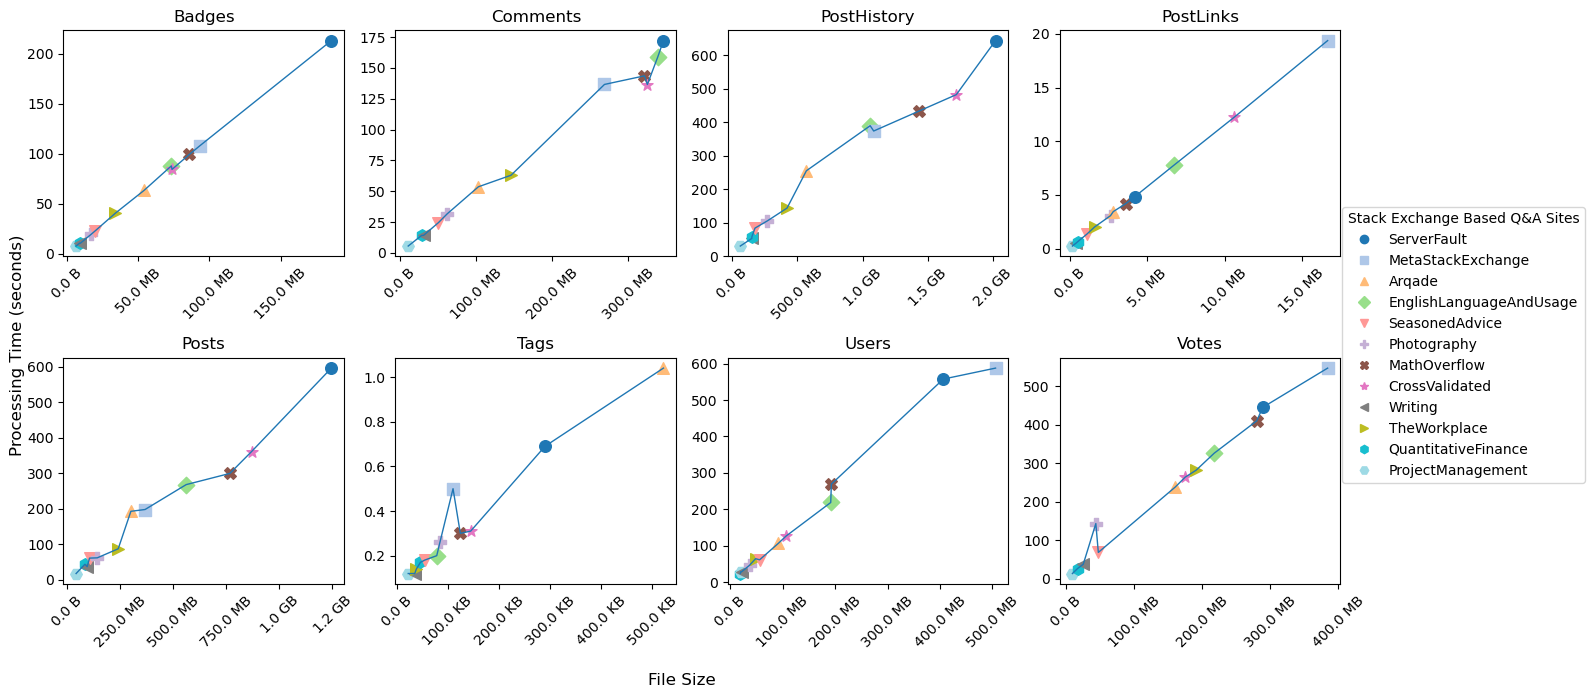

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

n_entities = 12
entities = ['ServerFault', #e1
            'MetaStackExchange', #e2
            'Arqade',#e3
            'EnglishLanguageAndUsage',#e4
            'SeasonedAdvice', #e5
            'Photography', #e6
            'MathOverflow', #e7
            'CrossValidated', #e8
            'Writing',#e9
            'TheWorkplace', #e10
            'QuantitativeFinance', #e11
            'ProjectManagement' #e12
]

files = ['Badges','Comments','PostHistory','PostLinks','Posts','Tags','Users','Votes']
# Keys = file names, values = list of entity indices to skip
skip_entities = {
    'Badges': [],          # skip E1 in file a
    'Comments': [],           # skip none in file b
    'PostHistory': [],       # skip E3 and E6 in file c
    # ... continue for all files
}
# ------------------------------------------------
# DATA 
# sizes in BYTES
# times in SECONDS
# Each row = entity/site
# Each column = file type (badges, comments,..., votes)
# ------------------------------------------------

sizes = np.array([
# badges,       comments,     posthistory,  postlinks,   posts,       tags,     users,       votes
#E1   
[185734266.9,   346407567.4,  2018634629,   4183818.24,  1245540516,  290048,  406228828.2,  288756858.9],    
#E2 
[93092577.28,   268854886.4,  1084479242.24, 16672358.4, 367515402.24, 110090.24, 505927434.24,384135331.84],
#E3
[53980692.48, 102991134.72,   568516935.68,   2799697.92,    300689653.76, 521605.12,   91656028.16, 160411156.48],
#E4
[73222062.08, 339109478.4,    1057593753.6,    6731857.92,   561334190.08, 78243.84, 191407063.04, 217474662.4],
#E5
[19178455.04, 50467962.88, 174661304.32, 1090519.04, 105801318.4, 54589.44, 55689871.36,47301263.36],
#E6
[17049845.76, 61886955.52, 269913948.16, 2621440, 142239334.4, 84459.52, 36448501.76, 43631247.36],
#E7   
[85867888.64, 321346600.96, 1428076625.92, 3607101.44, 767054315.52, 124364.8, 192612925.44, 280001249.28 ],
#E8    
[73672949.76, 325247303.68, 1717986918.4, 10632560.64, 869479219.2, 144599.04, 106052976.64, 174912962.56],
#E9
[9143582.72, 30964449.28, 150397255.68, 406804.48, 94539612.16, 35256.32, 21275607.04, 25134366.72],
#E10
[33858519.04, 145856921.6, 420447518.72, 1593835.52, 240910336, 38328.32, 47982837.76, 191040061.44],
#E11
[8661237.76, 28238151.68, 150481141.76, 501012.48, 84116766.72, 46274.56, 18853396.48, 16840130.56],
#E12
[6228541.44, 10664017.92, 62023270.4, 153978.88, 42477813.76, 22425.6, 19681771.52, 9237954.56]
])
times = np.array([

# badges, comments,  posthistory, postlinks, posts, tags, users,  votes
#E1 ServerFault
[213.03 , 172.19 ,644.02   , 4.83   ,  595.81  , 0.69  , 557.50  , 444.68 ],
#E2 MetaStackExchange
[107.79 , 136.63 , 374.03   , 19.38   , 197.70  , 0.5 ,587.61   , 546.54 ],
#E3 Arqade
[63.34 , 53.58,  255.29 , 3.45  ,  192.66  , 1.04  , 106.83  , 238.38  ],
#E4 EnglishLanguageAndUsage
[87.86 , 159.21 ,  389.83  , 7.78  , 267.79   , 0.20  ,  218.67 ,  325.91 ],
#E5 SeasonedAdvice
[22.37 , 24.51, 84.10   , 1.35   ,  60.85  , 0.18  , 61.35  ,  68.69],
#E6 Photography 
[19.80  , 31.59, 105.82  , 3.07  ,  61.65 , 0.26  ,46.27  ,  143.55 ],
#E7 MathOverflow
[99.31 , 143.58,  432.95 , 4.19   ,  299.28 , 0.30 , 269.08  , 409.76  ],
#E8 CrossValidated
[84.33 , 136.56,  482.67 ,  12.25  , 360.79   , 0.31 ,  126.39 , 263.85 ],
#E9 Writing 
[10.51 , 14.21,  53.28 , 0.53   ,  36.67 , 0.12 , 28.49 ,  37.92],
#E10 TheWorkplace 
[40.64 , 62.93 , 143.97   , 2.02   ,  87.17  , 0.14  ,   64.41 , 281.95  ],
#E11 QuantitativeFinance
[10.68  , 14.07 , 57.98  ,0.65   , 43.64   , 0.17 ,  23.68, 26.97 ],
#E12 ProjectManagement
[7.80 ,  5.51,    30.57  ,  0.24  ,17.47  ,0.12,  28.61  , 13.98 ]
])

# ------------------------------------------------
# marker list
markers = [
'o','s','^','D','v','P','X','*','<','>','h','H'
]
colors = plt.cm.tab20(np.linspace(0,1,n_entities))
fig, axes = plt.subplots(2,4, figsize=(14,7))

# fig, axes = plt.subplots(2,4, figsize=(14,7), sharex=True, sharey=True)
axes = axes.flatten()
def size_formatter(x, pos):
    if x >= 1e9:
        return f'{x/1e9:.1f} GB'
    elif x >= 1e6:
        return f'{x/1e6:.1f} MB'
    elif x >= 1e3:
        return f'{x/1e3:.1f} KB'
    else:
        return f'{x} B'

for i, f in enumerate(files):
    # get skip indices for this file
    skip_idx = skip_entities.get(f, [])
    ax = axes[i]

    # collect values for this file across entities
    x_all = sizes[:, i]
    y_all = times[:, i]

    # sort by file size
    order = np.argsort(x_all)
    x_sorted = x_all[order]
    y_sorted = y_all[order]
    # Determine which indices to keep
    keep_mask = [idx not in skip_idx for idx in order]
    
    # Filter x and y for both scatter and trend line
    x_keep = x_sorted[keep_mask]
    y_keep = y_sorted[keep_mask]
    # scatter in sorted order
    for k, idx in enumerate(order):
        if idx in skip_idx:
            continue  # skip this entity
        ax.scatter(
            x_sorted[k],
            y_sorted[k],
            marker=markers[idx],
            color=colors[idx],
            s=70
        )

    # scalability trend line
    # ax.plot(x_sorted, y_sorted, linewidth=1)
    # Trend line using only kept entities
    ax.plot(x_keep, y_keep, linewidth=1)
    ax.set_title(f"{f}")
    # ax.set_xscale('log')
    ax.xaxis.set_major_formatter(FuncFormatter(size_formatter))
    # ax.grid(True, which='both')
    for ax in axes.flat:
        ax.tick_params(axis='x', rotation=45)
fig.supxlabel("File Size")
fig.supylabel("Processing Time (seconds)")

# legend
legend_elements=[]
for j,e in enumerate(entities):
    legend_elements.append(
        Line2D([0],[0],
        marker=markers[j % len(markers)],
        color=colors[j],
        linestyle='None',
        label=e)
    )

fig.legend(handles=legend_elements,
           loc='center right',
           bbox_to_anchor=(1.15,0.5),
           title="Stack Exchange Based Q&A Sites")


plt.tight_layout()
plt.show()